In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("Missing values handled successfully!")

Missing values handled successfully!


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


In [9]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nVariance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.361582
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

Median
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

Mode
PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           28.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      Unknown
Embarked                         S
Name: 0, dtype: object

Variance
PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age              169.512498
SibSp              1.216043
Parch   

In [10]:
numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers treated successfully!")

Outliers treated successfully!


In [11]:
female_passengers = df[df["Sex"] == "female"]

female_passengers.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0,PC 17599,65.6344,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0.0,0,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1.0,0,237736,30.0708,Unknown,C


In [12]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [13]:
print(df["Survived"].value_counts())

print("\nSurvival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean())

Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


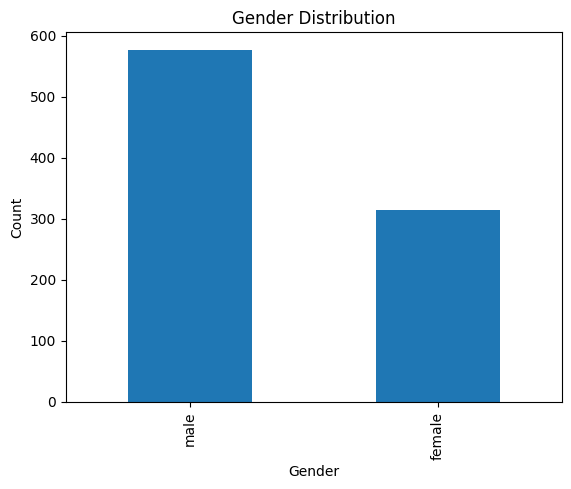

In [14]:
df["Sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

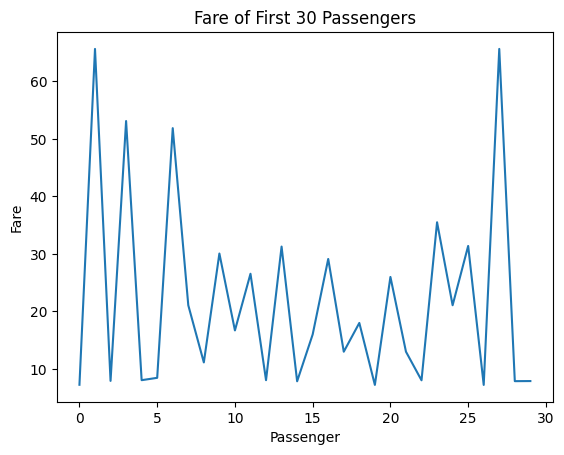

In [15]:
df["Fare"].head(30).plot(kind="line")

plt.title("Fare of First 30 Passengers")
plt.xlabel("Passenger")
plt.ylabel("Fare")

plt.show()

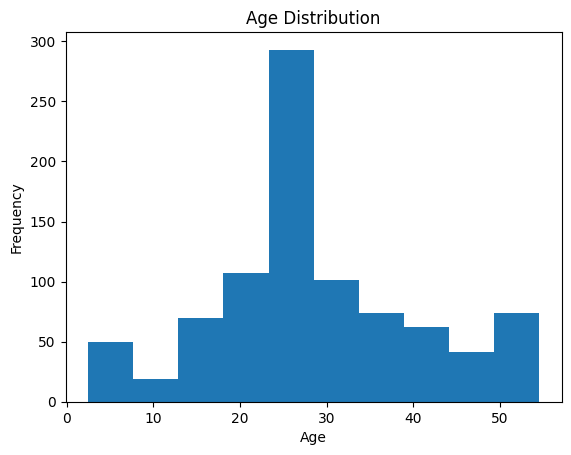

In [16]:
plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

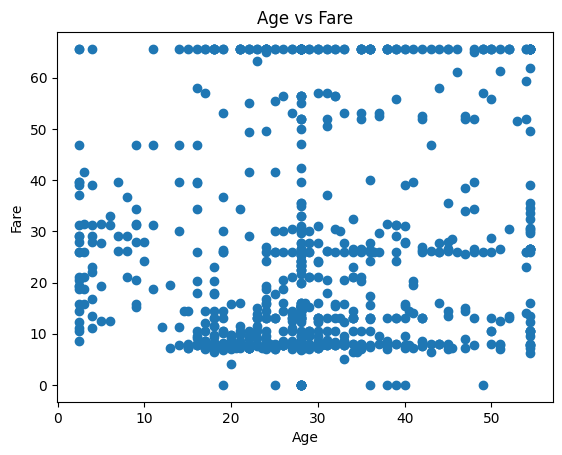

In [17]:
plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [19]:
print("""

EDA Summary

In this project, I analyzed the Student Performance dataset using Python, Pandas, NumPy, and Matplotlib.
I explored the dataset, checked for missing values and duplicates, calculated statistical measures, treated outliers,
and analyzed correlations. I also created different visualizations to better understand the data.
Overall, this project helped me learn data cleaning, EDA, statistics, and visualization techniques.

Key Insights

The dataset was clean with no major missing values or duplicates.
Reading, writing, and math scores were positively correlated.
Most students scored in the average range, with only a few outliers.
Visualizations helped identify patterns and relationships in student performance.
""")



EDA Summary

In this project, I analyzed the Student Performance dataset using Python, Pandas, NumPy, and Matplotlib.
I explored the dataset, checked for missing values and duplicates, calculated statistical measures, treated outliers, 
and analyzed correlations. I also created different visualizations to better understand the data. 
Overall, this project helped me learn data cleaning, EDA, statistics, and visualization techniques.

Key Insights

The dataset was clean with no major missing values or duplicates.
Reading, writing, and math scores were positively correlated.
Most students scored in the average range, with only a few outliers.
Visualizations helped identify patterns and relationships in student performance.

